# Fake News Detection with DistilBERT

This notebook is **Part 2 of 2** of a fake news detection project based on the Kaggle Fake and Real News dataset.

Notebook 1 showed that classical machine learning models trained on titles plus article bodies reached very high in-distribution scores, but failed to generalize reliably on a custom out-of-distribution benchmark. The main issue was shortcut learning: models exploited recurring dataset artifacts and source-specific patterns rather than robust semantic signals.

This notebook tests whether a transformer-based approach can improve generalization. We fine-tune **DistilBERT** using only headlines to reduce computational cost while still evaluating whether contextual representations are more robust than TF-IDF features.

## Main Objectives

- Fine-tune DistilBERT for binary fake news classification.
- Use only headlines to make GPU training feasible in Colab.
- Apply regularization through weight decay, dropout, and attention dropout.
- Save the fine-tuned checkpoint to Google Drive so training only needs to be run once.
- Compare DistilBERT against the classical ML baselines on the same custom robustness benchmark.

## From Classical Baselines to Transformer-Based NLP

The first notebook established a strong but fragile baseline: XGBoost, LinearSVC, and MLP models performed well on the Kaggle train/test split, yet struggled on custom real and synthetic headlines.

This second notebook tests whether DistilBERT can improve that behavior. Unlike TF-IDF models, DistilBERT produces contextual token representations, allowing the classifier to use word meaning and context rather than relying only on sparse lexical counts.

Because the original dataset is still biased, the goal is not to claim a production-ready fake news detector. The goal is to evaluate whether transformer-based feature learning, combined with regularization and targeted preprocessing, leads to better out-of-distribution behavior on a task similar to the training data.

In [1]:
import os

USE_COLAB = True
FORCE_RETRAIN = False  # set to True only when you intentionally want to fine-tune again

if USE_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    BASE_PATH = "/content/drive/MyDrive/fake_news_project"
else:
    BASE_PATH = "./fake_news_project"

DATA_PATH = os.path.join(BASE_PATH, "data")
MODEL_PATH = os.path.join(BASE_PATH, "distilbert_model")
RESULTS_PATH = os.path.join(BASE_PATH, "training_results")
LOGS_PATH = os.path.join(BASE_PATH, "training_logs")

MODEL_HAS_CONFIG = os.path.exists(os.path.join(MODEL_PATH, "config.json"))
MODEL_HAS_WEIGHTS = any(
    os.path.exists(os.path.join(MODEL_PATH, file_name))
    for file_name in ["model.safetensors", "pytorch_model.bin"]
)
MODEL_HAS_TOKENIZER = os.path.exists(os.path.join(MODEL_PATH, "tokenizer_config.json"))
MODEL_IS_SAVED = os.path.isdir(MODEL_PATH) and MODEL_HAS_CONFIG and MODEL_HAS_WEIGHTS and MODEL_HAS_TOKENIZER

print(f"Model path: {MODEL_PATH}")
print("Saved fine-tuned model found on Drive." if MODEL_IS_SAVED else "No saved fine-tuned model found yet.")

Mounted at /content/drive
Model path: /content/drive/MyDrive/fake_news_project/distilbert_model
Saved fine-tuned model found on Drive.


In [2]:
import pandas as pd
import numpy as np
import torch
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from datasets import Dataset

from transformers import (
    AutoConfig,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# load dataset from Google Drive or from a local project folder.
fake_path = os.path.join(DATA_PATH, "Fake.csv")
true_path = os.path.join(DATA_PATH, "True.csv")

# backward-compatible fallback for the current Drive layout.
if not os.path.exists(fake_path):
    fake_path = os.path.join(BASE_PATH, "Fake.csv")
if not os.path.exists(true_path):
    true_path = os.path.join(BASE_PATH, "True.csv")

fake = pd.read_csv(fake_path)
true = pd.read_csv(true_path)


In [5]:
fake['label'] = 0
true['label'] = 1
df = pd.concat([fake, true], ignore_index=True)
df['label'] = df['label'].astype(int)

In [6]:
df = df[["title","text", "label"]].drop_duplicates().dropna()
df.head(3)

,title,text,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",0


## Preprocessing: Reducing Explicit Shortcut Signals

As shown in Notebook 1, the Kaggle dataset contains strong source and formatting artifacts. The most visible example is Reuters-style boilerplate in many real-news articles.

Here we apply the same targeted cleaning strategy, but the modeling setup changes in an important way: **DistilBERT is trained only on headlines**, not on full article bodies. This choice reduces computation for Colab GPU training and focuses the experiment on concise, information-dense text.

Using only headlines also makes the custom robustness evaluation more consistent, since the custom benchmark is composed of headlines rather than full articles. The cleaning step reduces explicit shortcuts, while the transformer architecture is expected to capture richer contextual signals than classical TF-IDF features.

In [7]:
def clean_news_text(text):
    # removes Reuters
    text = re.sub(r'^.*\(Reuters\)\s*-\s*', '', text)

    # removes text in brackets
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub(r'\[[^\]]*\]', '', text)

    # optional: removes extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_data'] = df['title'].apply(clean_news_text).str.lower()

In [8]:
X = df["clean_data"]
y = df["label"]
X.shape, y.shape
X.head(3)

,clean_data
0,donald trump sends out embarrassing new year’s...
1,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke ...


In [9]:
# 25% data in test set for consistency
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## Tokenization with DistilBERT

We load the pre-trained distilbert-base-uncased tokenizer. Tokenization converts raw text into numerical "input IDs" and "attention masks". We set a maximum sequence length of 256 tokens to balance performance and computational cost.

In [10]:
model_name = "distilbert-base-uncased"

if MODEL_IS_SAVED and not FORCE_RETRAIN:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    print("Loaded fine-tuned tokenizer from Drive.")
else:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print("Loaded base tokenizer for first fine-tuning run.")


Loaded fine-tuned tokenizer from Drive.


## Converting to Hugging Face Dataset Format

We convert our Pandas dataframes into Hugging Face Dataset objects and apply the preprocessing function across the entire dataset in batches. Finally, we set the format to torch to make it compatible with the PyTorch training loop.

In [11]:
train_dataset = Dataset.from_dict({
    "text": X_train,
    "label": y_train
})

test_dataset = Dataset.from_dict({
    "text": X_test,
    "label": y_test
})

In [12]:
def preprocess(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=256)

train_dataset = train_dataset.map(preprocess, batched=True)
test_dataset = test_dataset.map(preprocess, batched=True)

Map:   0%|          | 0/29328 [00:00<?, ? examples/s]

Map:   0%|          | 0/9777 [00:00<?, ? examples/s]

In [13]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

## Model Initialization

We initialize `AutoModelForSequenceClassification` with DistilBERT and two output labels.

To reduce overfitting to the biased Kaggle distribution, the model uses both standard dropout and attention dropout. These regularization choices are important because the aim is not only to maximize benchmark accuracy, but to improve generalization on headlines that differ from the original training distribution.

If a fine-tuned checkpoint already exists on Google Drive, the notebook loads it directly instead of reinitializing the base model.


In [14]:
if MODEL_IS_SAVED and not FORCE_RETRAIN:
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
    print("Loaded fine-tuned model from Drive.")
else:
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=2,
        dropout=0.3,
        attention_dropout=0.3
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config
    )
    print("Initialized base DistilBERT model for fine-tuning.")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded fine-tuned model from Drive.


## Defining Evaluation Metrics

To monitor the model's performance, we define a function that calculates Accuracy, Precision, Recall, and the F1-Score. This function will be called by the Trainer during the evaluation phases.

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

## Training Configuration and Regularization

The training setup combines several regularization and stability choices:

- **Weight decay** through AdamW to discourage overly complex parameter updates.
- **Dropout and attention dropout** to reduce reliance on narrow shortcut features.
- **Cosine learning-rate scheduling with warmup** to make fine-tuning more stable.
- **Early stopping** to avoid unnecessary training once validation loss stops improving.

The model is trained for at most three epochs. Since the fine-tuned checkpoint is saved to Google Drive, this expensive GPU step only needs to be completed once.


In [16]:
training_args = TrainingArguments(
    output_dir=RESULTS_PATH,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    # optimizer and regularization
    optim="adamw_torch",
    adam_beta1=0.9,               # std value
    adam_beta2=0.999,             # std value
    adam_epsilon=1e-8,            # for stability

    weight_decay=0.1,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    logging_dir=LOGS_PATH,
    logging_steps=50,
    report_to="none"
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## Model Training and Drive Checkpointing

The fine-tuning process is managed through the Hugging Face `Trainer` API.

Before training, the notebook checks whether a complete fine-tuned model already exists in Google Drive. If it does, training is skipped and the saved checkpoint is reused. If it does not, the notebook requires a Colab GPU, fine-tunes the model, and saves both model weights and tokenizer.

This makes the workflow practical for project review: the notebook documents the full training pipeline, but it can also be rerun quickly on CPU after the model has been saved once.


In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [18]:
if MODEL_IS_SAVED and not FORCE_RETRAIN:
    print("Fine-tuned model already available on Drive: training skipped.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError(
            "No GPU available and no saved model found on Drive. "
            "Run this training cell once on Colab with GPU enabled, then keep FORCE_RETRAIN = False."
        )

    trainer.train()

    os.makedirs(MODEL_PATH, exist_ok=True)
    trainer.save_model(MODEL_PATH)
    tokenizer.save_pretrained(MODEL_PATH)

    MODEL_IS_SAVED = True
    print(f"Fine-tuned model and tokenizer saved to Drive: {MODEL_PATH}")


Fine-tuned model already available on Drive: training skipped.


## Loading the Fine-Tuned Model

After training or checkpoint detection, the fine-tuned model and tokenizer are loaded from Google Drive.

This ensures that all downstream evaluation cells use the same saved model, whether the notebook is executed on GPU or CPU. The following evaluation measures in-distribution benchmark performance on the Kaggle test split before moving to the custom robustness set.

In [19]:
# load the fine-tuned model from Drive for evaluation or CPU inference.
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model.to(device)

trainer = Trainer(
    model=model,
    args=training_args,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

results = trainer.evaluate()

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## Error Analysis Preparation

Aggregate metrics are not enough for this project, because the central question is whether the model generalizes beyond superficial patterns.

We therefore extract misclassified test examples together with confidence scores. These examples help identify residual weaknesses and show whether the model still relies on recurring dataset artifacts after transformer fine-tuning and regularization.

In [20]:
# convert logits into probabilities
probs = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

# confidence score = highest predicted probability
confidence_scores = probs.max(axis=1)

# create evaluation dataframe
results_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_true,
    "pred_label": y_pred,
    "confidence": confidence_scores
})

# extract misclassified examples
errors_df = results_df[
    results_df["true_label"] != results_df["pred_label"]
]

# save error analysis dataframe
errors_df.to_csv("errors.csv", index=False)

print(f"Number of misclassified examples: {len(errors_df)}")

Number of misclassified examples: 177


## Benchmark Performance: Classification Report

The classification report evaluates DistilBERT on the Kaggle test split. As expected, the in-distribution benchmark performance is very high: the model reaches about **98% accuracy and macro F1-score**.

The class-level results are also balanced. The model achieves **0.97 recall for fake news** and **0.99 recall for real news**, meaning that it retrieves almost all real-news examples in the benchmark set while maintaining strong performance on the fake class.

These results confirm that the fine-tuned transformer can learn the benchmark task effectively. However, as shown in Notebook 1, strong benchmark performance alone is not sufficient evidence of real generalization, so the custom robustness set remains the most important evaluation step.

In [21]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4477
           1       0.98      0.99      0.98      5300

    accuracy                           0.98      9777
   macro avg       0.98      0.98      0.98      9777
weighted avg       0.98      0.98      0.98      9777



## Benchmark Confusion Matrix

The confusion matrix provides a more concrete view of the benchmark errors. Most predictions fall on the diagonal, confirming that the model performs consistently on the original Kaggle distribution.

The small number of remaining errors is useful context for the custom evaluation: if the model later fails on out-of-distribution examples, that drop is unlikely to be caused by general underfitting. Instead, it reflects the harder problem of transferring beyond the dataset's original source and formatting patterns.

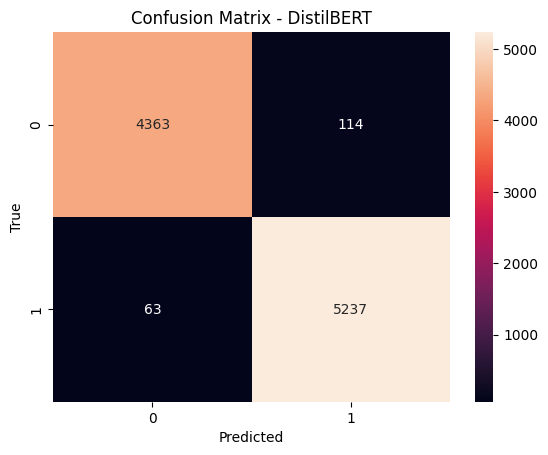

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Error Analysis: Investigating Misclassifications

Finally, we iterate through the test set to find cases where the model's prediction was wrong. By inspecting these "Error Cases" manually, we can understand if the model is still relying on hidden shortcuts or if the news pieces are genuinely ambiguous.

In [23]:
error_cases_found = 0
max_errors_to_display = 5

for i in range(len(y_pred)): # iterate through all predictions
    if y_pred[i] != y_true[i]:
        if error_cases_found < max_errors_to_display: # limit the number of error cases displayed
            print("\n--- ERROR CASE ---")
            print("Text:", X_test.iloc[i][:300])
            print("True:", y_true[i], "Pred:", y_pred[i])
            error_cases_found += 1
        else:
            break # stop printing after 'max_errors_to_display' errors are found


--- ERROR CASE ---
Text: former president george h.w. bush watched inaugural from hospital room
True: 1 Pred: 0

--- ERROR CASE ---
Text: democrats introduce legislation to probe russian voting hacks, trump pissed
True: 0 Pred: 1

--- ERROR CASE ---
Text: virginia seeks to hold trump in contempt for ignoring federal court order against muslim ban
True: 0 Pred: 1

--- ERROR CASE ---
Text: they held a convention in cleveland, and few protesters came
True: 1 Pred: 0

--- ERROR CASE ---
Text: nothing about those 50,000 jobs from japan is what trump says it is
True: 0 Pred: 1


## Custom Dataset for Robustness Evaluation

The custom benchmark is the same stress test used in Notebook 1, allowing a direct qualitative comparison between classical ML models and DistilBERT.

It contains two groups of examples:

- **Synthetic fake headlines**, generated to resemble plausible journalistic language. Some are close to the political distribution of the Kaggle dataset, while others focus on climate, sustainability, and energy.
- **Real headlines from Reuters and AP News**, including both political and climate/energy topics.

This evaluation is intentionally small and qualitative. Its purpose is not to claim production-level performance, but to test whether the model transfers better than classical ML baselines when the examples move outside the original training distribution.

In [24]:
fake_custom_sentences = [
    "President Donald said on Tuesday that talks with GOP officials were progressing after recent policy discussions",
    "Hillary Clinton told Reuters on Wednesday that new proposals would be reviewed following recent developments in Congress",
    "President Barack said on Thursday in a Reuters interview that long-term reforms remain a priority heading into November",
    "White House officials said on Monday that new sanctions against Iran would be delayed pending talks with European allies",
    "Senate Republicans introduced a revised immigration proposal after overnight negotiations with Democratic lawmakers",
    "Federal Reserve officials discussed possible emergency measures following renewed concerns over regional bank stability",
    "U.S. officials told reporters that military advisers would remain in eastern Syria despite earlier withdrawal plans",
    "Supreme Court conservatives appeared divided during arguments over state restrictions on early voting access",
    "State Department officials confirmed that trade negotiations with China would resume next month in Singapore",
    "Donald Trump told supporters during a rally in Ohio that new tariffs on imported vehicles were under consideration",
    # climate and energy
    "NASA researchers admitted in a leaked memo that Arctic ice levels have actually increased by 20% since 2010",
    "Energy Department engineers successfully tested a new cold fusion reactor that provides unlimited power at zero cost",
    "A new United Nations directive mandates that all internal combustion engine vehicles must be scrapped by the end of 2027",
    "Federal regulators announced a permanent national ceiling on gasoline prices to combat inflation effectively",
    "Climatologists at the European Space Agency confirmed that the recent cooling of the sun's surface will reverse global warming by 2030",
    "Global energy giants discovered an untapped oil field beneath the Atlantic that could power the planet for three centuries",
    "A secret government report indicates that offshore wind farms are causing a permanent shift in regional weather patterns",
    "Electric vehicle manufacturers face a federal probe after reports that recycled battery components are prone to spontaneous combustion",
    "The Environmental Protection Agency is planning a mandatory carbon tax for all residential homes starting in 2027",
    "New satellite data from a private research firm shows the Sahara Desert is rapidly turning green due to a sudden moisture surge"
]

true_custom_sentences = [
    "Louisiana delays U.S. House primary to draw new map after Supreme Court ruling",
    "Trump signs bill to fund DHS after lengthy shutdown over ICE operations",
    "White House says Iran war terminated as War Powers deadline arrives",
    "Warned off vaccine actions, Kennedy seeks quick health wins ahead of midterms",
    "U.S. prosecutor who lost job over AI-generated errors is rebuked by judge",
    "U.S. power grid operator PJM is considering market overhaul",
    "Maryland lawmakers await answers after air base jet fuel spill",
    "U.S. judge will not rubber-stamp Elon Musk settlement with SEC",
    "Democratic senators call early U.S. review of Disney station licenses 'abuse of power'",
    "Trump's crackdown on China-linked solar firms stalls U.S. factory boom",
    # climate and energy
    "Colorado River to hit record low after worst-ever Rockies snowpacks",
    "Enel reports rise in Q1 core profit, readies Brazil defence action",
    "BP to sell stakes in flagship UK carbon capture projects in Northern England",
    "Suspected oil spill seen on satellite images near Iran's Kharg Island export hub",
    "French utility Engie not changing Middle East strategy despite disruptions",
    # from AP News
    "What to know about the predictions for a potentially record-breaking El Nino",
    "Despite gains combating deforestation in Brazil’s Amazon, forest degradation is a looming threat",
    "Agency will move forward with plans to propose weakening some Biden-era PFAS limits, official says",
    "Scientists say don’t forget about plants. Climate change is endangering tens of thousands of species",
    "Planes and ships could run on kelp someday, but there are serious hurdles"
]


In [25]:
# merge synthetic headlines and corresponding real labels
synthetic_headlines = fake_custom_sentences + true_custom_sentences

synthetic_labels = (
    [0] * len(fake_custom_sentences) +
    [1] * len(true_custom_sentences)
)

# tokenize synthetic evaluation samples
synthetic_encodings = tokenizer(
    synthetic_headlines,
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

synthetic_encodings = {
    k: v.to(device)
    for k, v in synthetic_encodings.items()
}

# move model to device
model.to(device)
model.eval()

# run inference
with torch.no_grad():
    outputs = model(**synthetic_encodings)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1).cpu().numpy()
    confidence_scores = probs.max(dim=1).values.cpu().numpy()

In [26]:
print(
    f"{'Headline':<85} | "
    f"{'True':<5} | "
    f"{'Pred':<5} | "
    f"{'Confidence'}"
)

print("-" * 125)

for headline, true_label, pred, conf in zip(
    synthetic_headlines,
    synthetic_labels,
    preds,
    confidence_scores
):

    true_name = "REAL" if true_label == 1 else "FAKE"
    pred_name = "REAL" if pred == 1 else "FAKE"

    print(
        f"{headline[:80]:<85} | "
        f"{true_name:<5} | "
        f"{pred_name:<5} | "
        f"{conf:.4f}"
    )

Headline                                                                              | True  | Pred  | Confidence
-----------------------------------------------------------------------------------------------------------------------------
President Donald said on Tuesday that talks with GOP officials were progressing       | FAKE  | FAKE  | 0.9983
Hillary Clinton told Reuters on Wednesday that new proposals would be reviewed f      | FAKE  | FAKE  | 0.9022
President Barack said on Thursday in a Reuters interview that long-term reforms       | FAKE  | REAL  | 0.7385
White House officials said on Monday that new sanctions against Iran would be de      | FAKE  | REAL  | 0.9970
Senate Republicans introduced a revised immigration proposal after overnight neg      | FAKE  | REAL  | 0.9763
Federal Reserve officials discussed possible emergency measures following renewe      | FAKE  | REAL  | 0.9929
U.S. officials told reporters that military advisers would remain in eastern Syr      | FAKE 

In [27]:
# compute evaluation metrics on synthetic robustness samples
synthetic_accuracy = accuracy_score(synthetic_labels, preds)
synthetic_precision = precision_score(synthetic_labels, preds)
synthetic_recall = recall_score(synthetic_labels, preds)
synthetic_f1 = f1_score(synthetic_labels, preds)

# classification report

print("Classification Report")

print(
    classification_report(
        synthetic_labels,
        preds,
        target_names=["FAKE", "REAL"]
    )
)

Classification Report
              precision    recall  f1-score   support

        FAKE       0.75      0.60      0.67        20
        REAL       0.67      0.80      0.73        20

    accuracy                           0.70        40
   macro avg       0.71      0.70      0.70        40
weighted avg       0.71      0.70      0.70        40



## Custom Benchmark Results

On the custom robustness set, DistilBERT reaches **0.70 accuracy** and **0.70 macro F1-score**. This is lower than the Kaggle benchmark, but it is meaningfully stronger than the classical ML models from Notebook 1, which collapsed much more sharply on the same type of out-of-distribution examples.

The most relevant result is the behavior on real news. The model obtains **0.80 recall for the REAL class**, showing that it can identify many real headlines even when they come from sources and domains outside the original train/test split. In particular, the Reuters-style real headlines are recognized very reliably, supporting the idea that the transformer learned contextual reporting patterns rather than relying only on exact dataset artifacts.

The main weakness is the FAKE class, where recall drops to **0.60**. Several generated fake headlines are written in a formal journalistic style, and the model sometimes classifies them as real. This suggests that, although DistilBERT generalizes better than the classical baselines, it can still be influenced by realistic news formatting.

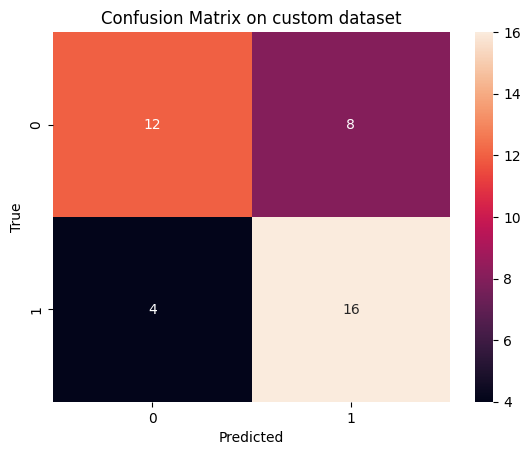

In [28]:
cm = confusion_matrix(synthetic_labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix on custom dataset")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Source-Level Interpretation

The custom predictions show a useful source-level pattern. DistilBERT handles Reuters-style real headlines particularly well, including examples outside the original topic distribution. This explains the strong REAL recall and marks a clear improvement over the classical ML models, which struggled to identify real news once the strongest dataset shortcuts were removed.

AP News examples are more challenging. Some AP headlines use less Reuters-like phrasing, broader explanatory formats, or climate/science topics that are farther from the political distribution of the Kaggle dataset. These examples account for a noticeable share of the remaining false negatives.

The synthetic fake headlines are also difficult when they imitate institutional or journalistic language. This is an important limitation: the model is more robust, but it has not fully learned factuality. It is still solving a text classification task shaped by the training data distribution.

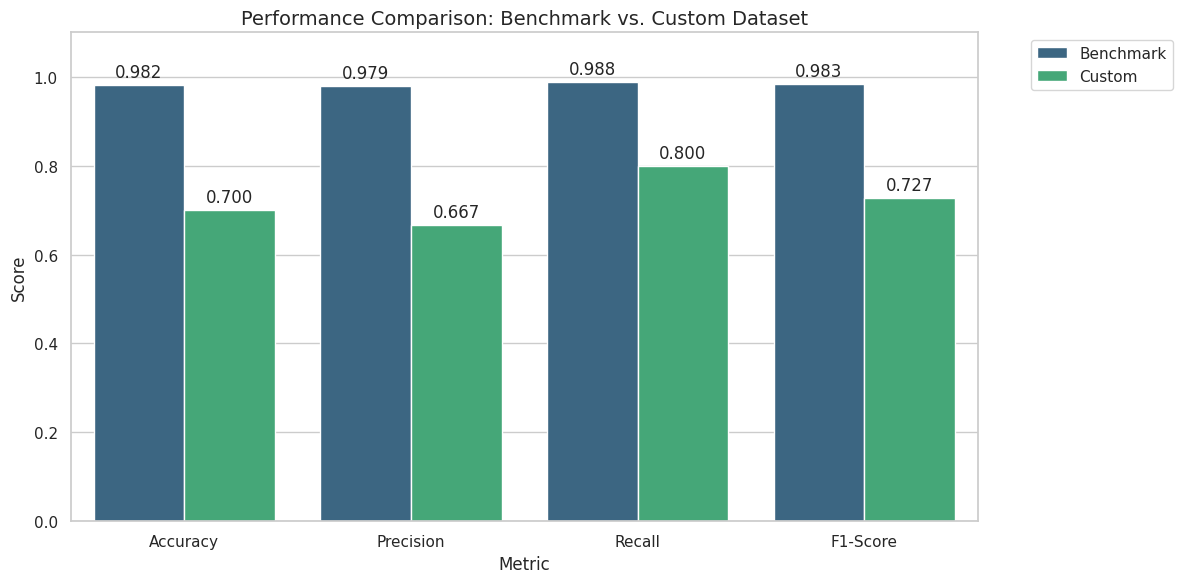

In [29]:
# automatic extraction from original test set
# metrics are pulled from the trainer's 'results' object
bench_a = results.get('eval_accuracy', 0)
bench_p = results.get('eval_precision', 0)
bench_r = results.get('eval_recall', 0)
bench_f1 = results.get('eval_f1', 0)

# automatic extraction from the custom dataset
cust_a = synthetic_accuracy
cust_p = synthetic_precision
cust_r = synthetic_recall
cust_f1 = synthetic_f1

# 3. Create the DataFrame for plotting
# Note: Data is translated to English and labeled as "Custom"
data = {
    'Dataset': ['Benchmark'] * 4 + ['Custom'] * 4,
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score',
               'Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [bench_a, bench_p, bench_r, bench_f1,
              cust_a, cust_p, cust_r, cust_f1]
}
df_plot = pd.DataFrame(data)

# 4. Generate the visualization
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Metric', y='Value', hue='Dataset', data=df_plot, palette='viridis')

# Add value labels on top of the bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)

plt.ylim(0, 1.1)
plt.title('Performance Comparison: Benchmark vs. Custom Dataset', fontsize=14)
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Final Interpretation and Future Work

Compared with the classical ML models from Notebook 1, the fine-tuned DistilBERT model shows substantially better out-of-distribution generalization.

The benchmark results confirm strong in-distribution learning, while the custom benchmark gives a more realistic picture: the model performs well overall, identifies many real Reuters-style headlines even outside the original distribution, and maintains acceptable aggregate performance on a harder custom set. At the same time, it still struggles with some AP News headlines and with synthetic fake headlines that closely mimic formal news formatting.

This supports the main conclusion of the project: **transformer-based models such as DistilBERT, when fine-tuned with appropriate regularization choices, can generalize better than traditional TF-IDF-based ML models on similar out-of-distribution NLP tasks**. The improvement comes from the combination of contextual representations, targeted preprocessing, weight decay, dropout, attention dropout, early stopping, and a more careful evaluation design.

The project also highlights an important methodological lesson: high benchmark accuracy is not enough. A stronger NLP workflow should include bias analysis, shortcut-learning diagnostics, interpretable baselines, transformer fine-tuning, and custom robustness evaluation.

## Future Work

A natural next step would be to compare this fine-tuned classifier with **prompt-based LLM classification**, evaluating whether instruction-tuned language models can better reason over ambiguous or stylistically realistic headlines.

It would also be useful to expand the custom benchmark into a larger and more diverse evaluation set, with clearer source labels, more topics, more outlets, and a broader range of synthetic fake-news styles. This would make the robustness analysis more reliable and allow a stronger comparison between classical ML, fine-tuned transformers, and LLM prompting.
